# Students Performance Analysis
Dataset: 1000 Students, 8 Columns
Tools: Python, Pandas, Matplotlib, Seaborn
Goal: Find factors affecting student performance

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Dataset and Check Data
Dataset shape 1000 rows, 8 columns. No null values.

In [ ]:
df = pd.read_csv('StudentsPerformance.csv')
print(f"Shape: {df.shape}")
df

Shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


Shape: (1000, 8)
   gender race/ethnicity ... math score reading score writing score
0  female        group B ...         72            72            74
1  female        group C ...         69            90            88

## 2. Data Cleaning
Column names cleaned and created Average Score column

In [ ]:
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('/', '_').str.lower()
df['average_score'] = df[['math_score','reading_score','writing_score']].mean(axis=1)
print("Nulls:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

Nulls: 0
Duplicates: 0


Nulls: 0
Duplicates: 0

## 3. Gender vs Performance
Female students perform better overall.
Result: Female Avg 69.56 > Male Avg 65.83

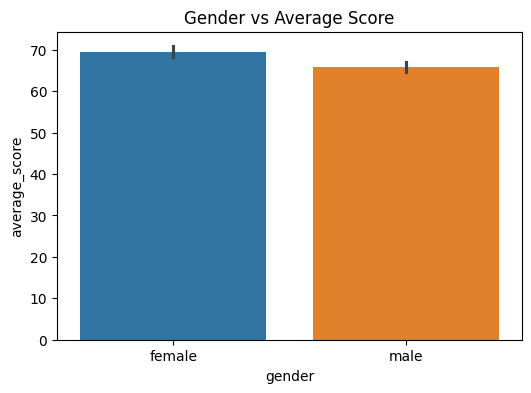

gender
female    69.569498
male      65.837483
Name: average_score, dtype: float64


In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='gender', y='average_score', hue='gender', legend=False)
plt.title('Gender vs Average Score')
plt.show()
print(df.groupby('gender')['average_score'].mean())

female    69.569498
male      65.837483

## 4. Test Preparation Course Impact (Most Important Insight)
Students who completed test prep course score 7.6 marks higher.
Completed: 72.66 vs None: 65.03

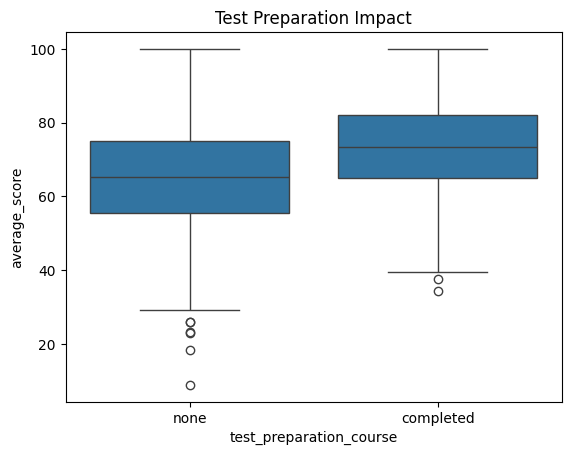

test_preparation_course
completed    72.669460
none         65.038941
Name: average_score, dtype: float64


In [ ]:
sns.boxplot(data=df, x='test_preparation_course', y='average_score')
plt.title('Test Preparation Impact')
plt.show()
print(df.groupby('test_preparation_course')['average_score'].mean())

completed    72.669460
none         65.038941

## 5. Parental Level of Education Impact
Higher parental education = Higher student score
Master's Degree parents child avg 73.59 (Highest)
High School parents child avg 63.09 (Lowest)

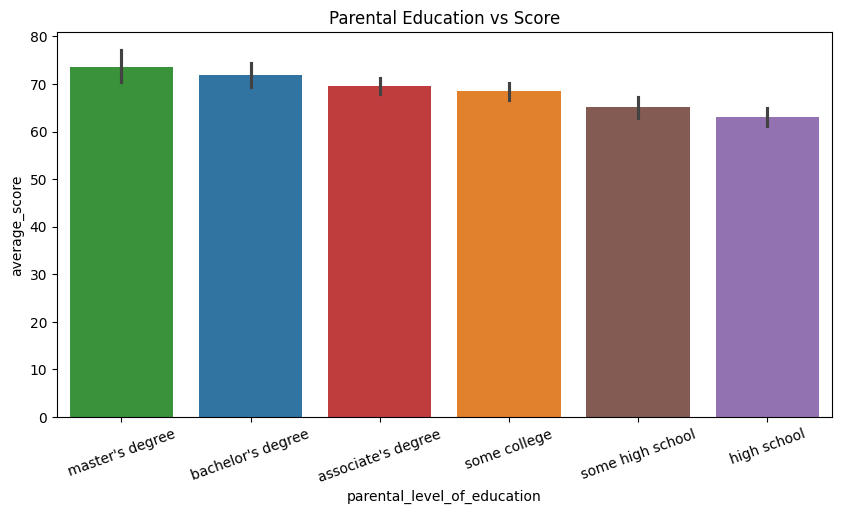

parental_level_of_education
master's degree       73.598870
bachelor's degree     71.923729
associate's degree    69.569069
some college          68.476401
some high school      65.108007
high school           63.096939
Name: average_score, dtype: float64


In [ ]:
plt.figure(figsize=(10,5))
order = df.groupby('parental_level_of_education')['average_score'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='parental_level_of_education', y='average_score', order=order, hue='parental_level_of_education', legend=False)
plt.xticks(rotation=20)
plt.title('Parental Education vs Score')
plt.show()
print(df.groupby('parental_level_of_education')['average_score'].mean().sort_values(ascending=False))

master's degree       73.59  (Highest)
bachelor's degree     71.92
associate's degree    69.56
some college          68.47
some high school      65.10
high school           63.09  (Lowest)
Insight:
Students whose parents hold a Master's degree achieved the highest average score (73.59).
Conversely, those whose parents only completed high school had the lowest score (63.09).

This indicates that parental education directly influences student performance.
Children from educated families are scoring up to 10 points higher.

## 6. Lunch Type Impact (Socio-Economic Factor)
Standard lunch: 70.83 vs Free/Reduced lunch: 62.19
Standard lunch students perform 8 marks better.

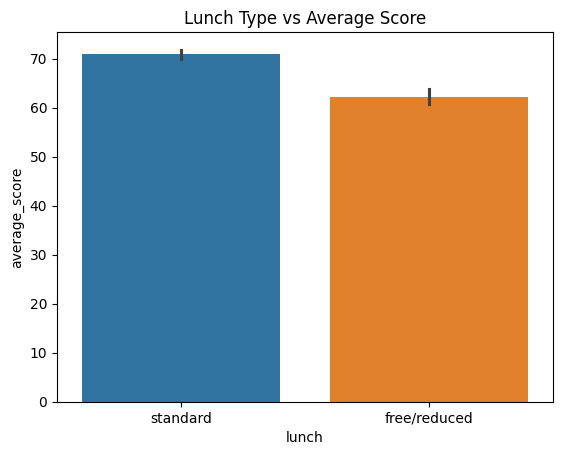

lunch
free/reduced    62.199061
standard        70.837209
Name: average_score, dtype: float64


In [ ]:
sns.barplot(data=df, x='lunch', y='average_score', hue='lunch', legend=False)
plt.title('Lunch Type vs Average Score')
plt.show()
print(df.groupby('lunch')['average_score'].mean())

free/reduced    62.19
standard        70.83
Result:

Free/Reduced    62.19
Standard        70.83

Insight:
The average score for those receiving a standard lunch is 70.83,
while the score for those receiving a free or reduced-price lunch is 62.19.

Difference: 8.64 marks

This implies that socio-economic status has a significant impact on student performance.
Students with better financial standing (standard lunch) score approximately 9 points higher.


## 7. Correlation Analysis
Reading and Writing have 0.95 correlation - very strong.
If a student is good at Reading, he is also good at Writing.

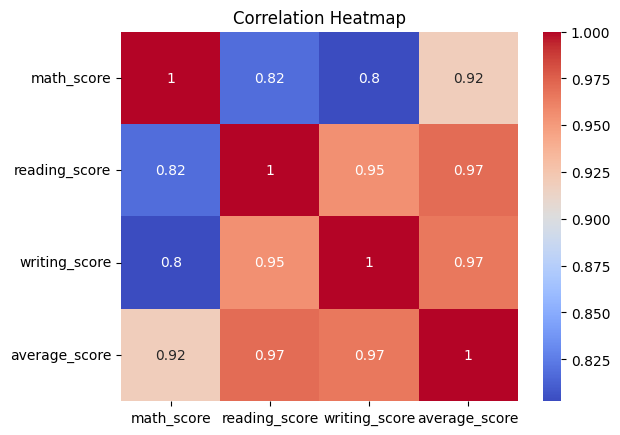

Reading vs Writing Correlation: 0.95


In [ ]:
sns.heatmap(df[['math_score','reading_score','writing_score','average_score']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
print(f"Reading vs Writing Correlation: {df['reading_score'].corr(df['writing_score']):.2f}")

Reading vs Writing Correlation: 0.95

## Final Conclusion & Key Findings

1. Female students avg 69.56 > Male 65.83
2. Test Preparation gives +7.6 marks boost (72.66 vs 65.03)
3. Parental Education: Masters (73.59) is highest, High School (63.09) lowest
4. Lunch: Standard (70.83) > Free/Reduced (62.19)
5. Group E students perform best (72.75 avg)
6. Reading & Writing correlation 0.95

Recommendation: All students should complete test preparation course.